# Netflix Recommendation Engine

In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import warnings
warnings.filterwarnings('ignore')

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
# Load the Movie_titles.csv Dataset

movies = pd.read_csv('movie_titles.csv',encoding = "ISO-8859-1", header=None, names=['movieId', 'year_of_release', 'title'], usecols=[0,1,2])

In [3]:
movies.head()

,movieId,year_of_release,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [4]:
# Parse the combined_data_1.txt dataset (Big Rating File)

file_path = 'combined_data_1.txt'

movie_ids = []
user_ids = []
ratings = []

with open(file_path, 'r') as file:
    current_movie_id = None
    for line in file:
        line = line.strip()
        if line.endswith(':'):
            current_movie_id = int(line[:-1])
        else:
            parts = line.split(',')
            user_ids.append(int(parts[0]))
            ratings.append(float(parts[1]))
            movie_ids.append(current_movie_id)

In [5]:
# Create the Rating DataFrame

rating_df = pd.DataFrame({
    'userId': user_ids,
    'movieId': movie_ids,
    'rating': ratings
})

In [6]:
rating_df.head()

,userId,movieId,rating
0,1488844,1,3.0
1,822109,1,5.0
2,885013,1,4.0
3,30878,1,4.0
4,823519,1,3.0


In [7]:
# Merge Rating_df and movies

movie_data = pd.merge(rating_df, movies, on = 'movieId', how = 'left')

In [8]:
movie_data.head()

,userId,movieId,rating,year_of_release,title
0,1488844,1,3.0,2003.0,Dinosaur Planet
1,822109,1,5.0,2003.0,Dinosaur Planet
2,885013,1,4.0,2003.0,Dinosaur Planet
3,30878,1,4.0,2003.0,Dinosaur Planet
4,823519,1,3.0,2003.0,Dinosaur Planet


In [9]:
# Assign Random Genres

genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Romance', 'Sci-Fi', 'Thriller', 'Animation']
movies['genre'] = [random.choice(genres) for _ in range(len(movies))]

In [10]:
# Merge again with genres
movies_data = pd.merge(rating_df, movies, on='movieId', how='left')

In [11]:
print(movies_data[['movieId', 'title', 'genre']].head())

   movieId            title   genre
0        1  Dinosaur Planet  Comedy
1        1  Dinosaur Planet  Comedy
2        1  Dinosaur Planet  Comedy
3        1  Dinosaur Planet  Comedy
4        1  Dinosaur Planet  Comedy


In [12]:
# EDA (Exploratory Data Analysis)

# Check for Missing values

movies_data.isnull().sum()

userId               0
movieId              0
rating               0
year_of_release    189
title                0
genre                0
dtype: int64

In [13]:
# Basic Statistics

movies_data.describe()

,userId,movieId,rating,year_of_release
count,2.405376e+07,2.405376e+07,2.405376e+07,2.405358e+07
mean,1.322285e+06,2.308324e+03,3.599634e+00,1.994406e+03
std,7.645779e+05,1.303909e+03,1.086118e+00,1.259927e+01
min,6.000000e+00,1.000000e+00,1.000000e+00,1.915000e+03
25%,6.609270e+05,1.180000e+03,3.000000e+00,1.991000e+03
50%,1.318602e+06,2.342000e+03,4.000000e+00,1.999000e+03
75%,1.984358e+06,3.433000e+03,4.000000e+00,2.003000e+03
max,2.649429e+06,4.499000e+03,5.000000e+00,2.005000e+03


In [14]:
# Number of unique users

movies_data['userId'].nunique()

470758

In [15]:
# Number of unique movies

movies_data['movieId'].nunique()

4499

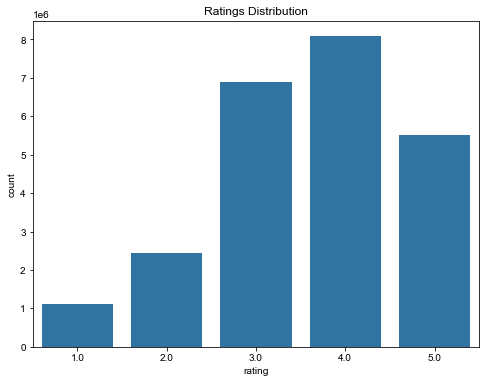

In [16]:
# Distribution of Ratings
from matplotlib import rcParams, font_manager
rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8,6))
sns.countplot(x='rating', data=movies_data)
plt.title('Ratings Distribution')
plt.show()

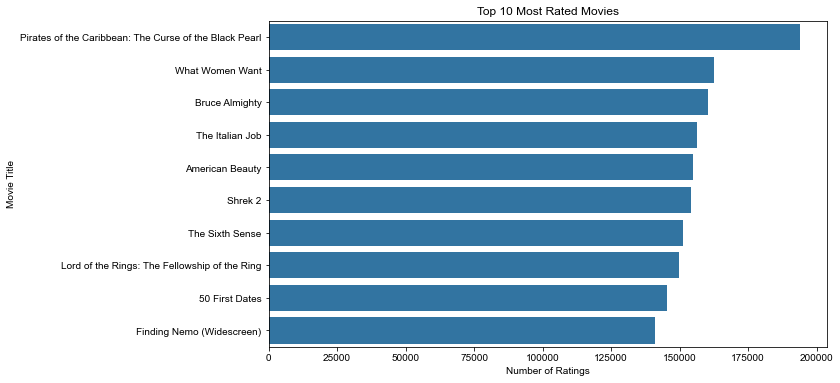

In [17]:
# Top 10 Most Rated Movies

top_movies = movies_data['title'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_movies.values, y=top_movies.index)
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()

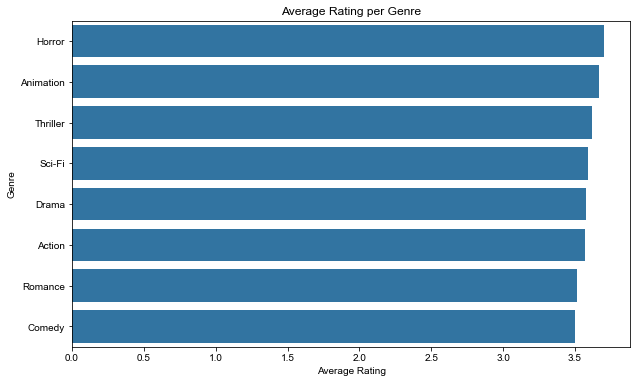

In [18]:
# Average Rating per Genre

avg_rating_per_genre = movies_data.groupby('genre')['rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating_per_genre.values, y=avg_rating_per_genre.index)
plt.title('Average Rating per Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()

In [19]:
# Build Recommendation Model using SVD

# Model Implementation
!pip install scikit-surprise


[notice] A new release of pip is available: 25.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\Priya\anaconda3\lib\site-packages\pip\_internal\cli\base_command.py", line 106, in _run_wrapper
    status = _inner_run()
  File "C:\Users\Priya\anaconda3\lib\site-packages\pip\_internal\cli\base_command.py", line 97, in _inner_run
    return self.run(options, args)
  File "C:\Users\Priya\anaconda3\lib\site-packages\pip\_internal\cli\req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "C:\Users\Priya\anaconda3\lib\site-packages\pip\_internal\commands\install.py", line 484, in run
    installed_versions[distribution.canonical_name] = distribution.version
  File "C:\Users\Priya\anaconda3\lib\site-packages\pip\_internal\metadata\pkg_resources.py", line 192, in version
    return parse_version(self._dist.version)
  File "C:\Users\Priya\anaconda3\lib\site-packages\pip\_ven

In [24]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import cross_validate

In [25]:
# Prepare data for Surprise library
reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(movies_data[['userId', 'movieId', 'rating']][:1000000], reader)

In [26]:
# Build SVD model

svd = SVD()

In [27]:
# Evaluate Model

cross_validate(svd, surprise_data, measures = ['RMSE'], cv = 3)

{'test_rmse': array([0.99040188, 0.991148  , 0.99155572]),
 'fit_time': (8.928943872451782, 8.485219240188599, 9.000432968139648),
 'test_time': (4.011526107788086, 3.130025863647461, 4.26669454574585)}

In [28]:
# Recommend Top Movie for Each Genre to a User

# Pick a random user

user_id = random.choice(movies_data['userId'].unique())
user_id

1570230

In [29]:
recommendations = []

for genre in genres:
    # Filter movies of that genre
    
    genre_movies = movies[movies['genre'] == genre]

    # Predict ratings for all movies in that genre
    
    genre_movies['predicted_rating'] = genre_movies['movieId'].apply(lambda x: svd.predict(user_id, x).est)

    # Recommend the highest predicted rated movie in that genre
    
    top_movie = genre_movies.sort_values('predicted_rating', ascending=False).iloc[0]

    recommendations.append((genre, top_movie['title'], top_movie['predicted_rating']))

In [30]:
# Show Recommendations

for genre, title, rating in recommendations:
    print(f"Genre: {genre} -> Recommended Movie: {title} (Predicted Rating: {rating:.2f})")

Genre: Action -> Recommended Movie: That '70s Show: Season 1 (Predicted Rating: 4.17)
Genre: Comedy -> Recommended Movie: Ninotchka (Predicted Rating: 3.96)
Genre: Drama -> Recommended Movie: Elfen Lied (Predicted Rating: 4.17)
Genre: Horror -> Recommended Movie: Invader Zim (Predicted Rating: 4.14)
Genre: Romance -> Recommended Movie: The Battle of Algiers: Bonus Material (Predicted Rating: 4.02)
Genre: Sci-Fi -> Recommended Movie: Lord of the Rings: The Return of the King: Extended Edition: Bonus Material (Predicted Rating: 4.45)
Genre: Thriller -> Recommended Movie: Chappelle's Show: Season 1 (Predicted Rating: 4.22)
Genre: Animation -> Recommended Movie: Aqua Teen Hunger Force: Vol. 1 (Predicted Rating: 4.20)


In [31]:
# Find Best and Worst Rated Genres

# Best Rated Genre

best_genre = avg_rating_per_genre.idxmax()
print(f"Best Rated Genre: {best_genre} with average rating {avg_rating_per_genre.max():.2f}")

Best Rated Genre: Horror with average rating 3.70


In [32]:
# Worst Rated Genre

worst_genre = avg_rating_per_genre.idxmin()
print(f"Worst Rated Genre: {worst_genre} with average rating {avg_rating_per_genre.min():.2f}")

Worst Rated Genre: Comedy with average rating 3.50
